Esta celda importa pandas, lee los datos y limpia los nombres de las columnas.

In [ ]:
import pandas as pd
datos = pd.read_csv("celsius.csv")
datos.columns = datos.columns.str.strip()

Esta celda muestra las primeras filas del DataFrame.

In [ ]:
datos.head()


,Celsius,Fahrenheit
0,-40,-40.0
1,-10,14.0
2,0,32.0
3,8,46.4
4,15,59.0


Esta celda extrae los valores de Celsius como características de entrada (x).

In [ ]:
datos["Celsius"].values



array([-40, -10,   0,   8,  15,  22,  38])

Esta celda extrae los valores de Fahrenheit como etiquetas objetivo (y).

In [ ]:
datos["Fahrenheit"].values

array([-40. ,  14. ,  32. ,  46.4,  59. ,  71.6, 100.4])

Esta celda importa TensorFlow, define y compila un modelo Keras para la conversión de Celsius a Fahrenheit.

In [ ]:
import tensorflow as tf

modelo = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])

modelo.compile(optimizer=tf.keras.optimizers.Adam(.1), loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Esta celda entrena el modelo Keras usando Celsius (x) y Fahrenheit (y) durante 1000 épocas.

In [ ]:
x = datos["Celsius"].values
y = datos["Fahrenheit"].values
entrenamiento = modelo.fit(x, y, epochs=1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step - loss: 2874.4192
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 2666.5037
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 2470.3340
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 2286.0884
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 2113.9084
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1953.8842
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 1806.0519
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 1670.3912
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1546.8132
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1435.1605
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1335.1993
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1246.6162
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1169.0160
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1101.9192
Epoch 15/1000
1/1 ━━━━━━━━━━

Esta celda importa matplotlib para graficar el historial de pérdida de entrenamiento.

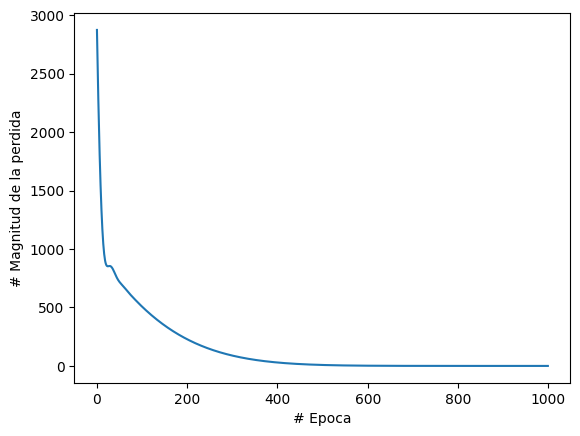

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.xlabel("# Epoca")
plt.ylabel("# Magnitud de la perdida")
plt.plot(entrenamiento.history.get('loss'))

Esta celda usa el modelo entrenado para predecir Fahrenheit para un valor Celsius dado e imprime el resultado.

In [ ]:
c = 1230
prediccion = modelo.predict([c])

print(f"prediccion: {c} celsius son {prediccion[0]} fahrenheit")

Esta celda imprime los pesos aprendidos de la capa densa del modelo.

In [ ]:
print(modelo.layers[0].get_weights())

[array([[1.8002471]], dtype=float32), array([31.971045], dtype=float32)]
